# Project Phase II: Applied Data Engineering and Machine Learning

## TASK 2: Original LCS system on raw dataset

In [32]:
import pandas as pd

# Load the raw dataset and create a deep copy for further processing
df = pd.read_csv("../data/student-course-completion-prediction-dataset-trimmed.csv")
df_copy = df.copy(deep=True)

display(df_copy.head())

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [33]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}")

Student_ID: str, unique: 30000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 33
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 16
Average_Session_Duration_Min: int64, unique: 72
Video_Completion_Rate: float64, unique: 929
Discussion_Participation: int64, unique: 13
Time_Spent_Hours: float64, unique: 209
Days_Since_Last_Login: int64, unique: 71
Notifications_Checked: int64, unique: 19
Peer_Interaction_Score: float64, unique: 101
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 16
Quiz_Score_Avg: float64, unique: 668
Project_Grade: float64, unique: 811
Progress_Percentage: float64, uni

In [34]:
# Start from the raw working dataset
baseline_df = df_copy.copy()

# Remove columns that should not be predictors
baseline_df = baseline_df.drop(
    columns=[
        "Student_ID",  # identifier only
        "Name",  # free-text identifier
        "Completed_Status",
    ],
    errors="ignore",
)

# Convert Enrollment_Date only because eLCS needs numeric input
if "Enrollment_Date" in baseline_df.columns:
    baseline_df["Enrollment_Date"] = pd.to_datetime(
        baseline_df["Enrollment_Date"], dayfirst=True
    )

    baseline_df["Enrollment_Year"] = baseline_df["Enrollment_Date"].dt.year
    baseline_df["Enrollment_Month"] = baseline_df["Enrollment_Date"].dt.month
    baseline_df["Enrollment_Day"] = baseline_df["Enrollment_Date"].dt.day

    baseline_df = baseline_df.drop(columns=["Enrollment_Date"])

# Separate target from predictors
y_baseline = baseline_df["Completed"].copy()
X_baseline = baseline_df.drop(columns=["Completed"]).copy()

# Convert categorical predictors to numeric codes
categorical_cols = X_baseline.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].astype("category").cat.codes

# Convert target to binary numeric values
y_baseline = y_baseline.map({"Completed": 1, "Not Completed": 0})

# Verify that the minimally processed baseline is ready
print("Baseline feature shape:", X_baseline.shape)
print("Baseline target shape:", y_baseline.shape)

print("\nNon-numeric predictor columns:")
print(X_baseline.select_dtypes(exclude="number").columns.tolist())

print("\nMissing target values:")
print(y_baseline.isna().sum())

print("\nTarget classes:")
print(set(y_baseline))

Baseline feature shape: (30000, 39)
Baseline target shape: (30000,)

Non-numeric predictor columns:
[]

Missing target values:
0

Target classes:
{0, 1}


In [35]:
from sklearn.model_selection import train_test_split

# Split the minimally processed baseline data
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.20, random_state=42, stratify=y_baseline
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (24000, 39)
Testing features: (6000, 39)
Training target: (24000,)
Testing target: (6000,)

Training class distribution:
Completed
0    12166
1    11834
Name: count, dtype: int64

Testing class distribution:
Completed
0    3042
1    2958
Name: count, dtype: int64


In [ ]:
from skeLCS import eLCS

print("eLCS import successful")

# Create the original eLCS baseline model
baseline_elcs_model = eLCS(learning_iterations=5000, track_accuracy_while_fit=True)

print("Baseline eLCS model created.")

eLCS import successful
Baseline eLCS model created.


In [37]:
# Train the original eLCS model
baseline_elcs_model = baseline_elcs_model.fit(X_train.values, y_train.values)

print("eLCS training complete")

eLCS training complete


Original eLCS Baseline Performance
----------------------------------
Accuracy:          0.5145
Precision:         0.5093
Recall:            0.4165
F1 Score:          0.4582
Balanced Accuracy: 0.5131

Confusion Matrix:
[[1855 1187]
 [1726 1232]]
Roc/PRC curves


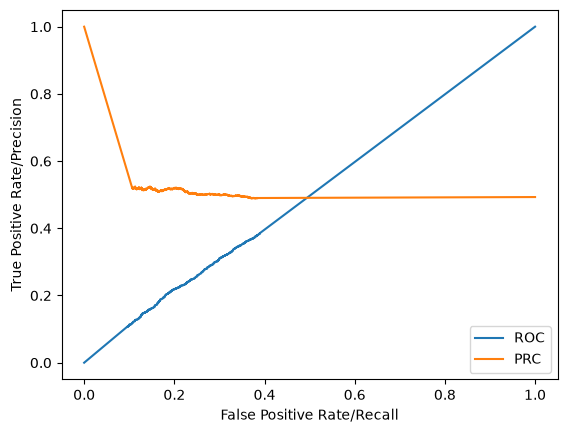

PRC AUC:0.5243026763557858
ROC AUC:0.5020303979579998
Final Training Accuracy: 0.5335485657241464
Final Instance Coverage: 0.873625
Final Attribute Specificity List: [409, 447, 374, 483, 433, 402, 454, 413, 425, 409, 527, 391, 397, 408, 400, 405, 457, 458, 470, 407, 434, 433, 436, 419, 430, 422, 443, 421, 414, 488, 448, 428, 434, 456, 397, 425, 409, 412, 449]
Final Attribute Accuracy List: [394.3457382953181, 428.83253738006056, 361.86939775910366, 449.80527444435194, 408.2798443300764, 383.2319862155389, 425.35470355667735, 394.5075153815193, 406.5688120702827, 384.80116959064327, 478.803444998414, 369.6023688252891, 373.4109592162223, 382.66706011351926, 383.8560864058542, 379.68545482295474, 415.7095649040502, 425.4702770397816, 428.2689149128927, 385.762836318738, 417.0406634254258, 402.2831568238403, 407.94803159455415, 401.15910151939545, 408.48097158218127, 391.01136887278534, 412.5468671245237, 389.11962886829383, 398.99937438292704, 441.48138502362144, 415.525212854717, 393.83

In [38]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Make predictions on the test dataset
y_pred_baseline = baseline_elcs_model.predict(X_test.values)
probabilities = baseline_elcs_model.predict_proba(X_test.values)


# Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
balanced_acc = balanced_accuracy_score(y_test, y_pred_baseline)
# Receiver Operating Characteristic curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilities[:, 1])
# Precision-Recall curve
precision_curve, recall_curve, thresholds_prc = precision_recall_curve(
    y_test, probabilities[:, 1]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

print("Original eLCS Baseline Performance")
print("----------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("Roc/PRC curves")
plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_curve, precision_curve, label="PRC")
plt.xlabel("False Positive Rate/Recall")
plt.ylabel("True Positive Rate/Precision")
plt.legend()
plt.show()
print("PRC AUC:" + str(auc(recall_curve, precision_curve)))
print("ROC AUC:" + str(auc(fpr, tpr)))


print("Final Training Accuracy: " + str(baseline_elcs_model.get_final_accuracy()))
print(
    "Final Instance Coverage: " + str(baseline_elcs_model.get_final_instance_coverage())
)
print(
    "Final Attribute Specificity List: "
    + str(baseline_elcs_model.get_final_attribute_specificity_list())
)
print(
    "Final Attribute Accuracy List: "
    + str(baseline_elcs_model.get_final_attribute_accuracy_list())
)

In [39]:
export_dir = "../data/export/"
baseline_iteration_tracking_file = (
    f"{export_dir}/baseline_elcs_model_iteration_data.csv"
)

baseline_elcs_model.export_iteration_tracking_data(baseline_iteration_tracking_file)
baseline_elcs_model_iteration_data = pd.read_csv(baseline_iteration_tracking_file)

display(baseline_elcs_model_iteration_data)

,Iteration,Accuracy (approx),Average Population Generality,Macropopulation Size,Micropopulation Size,Match Set Size,Correct Set Size,Average Iteration Age of Correct Set Classifiers,# Classifiers Subsumed in Iteration,# Crossover Operations Performed in Iteration,# Mutation Operations Performed in Iteration,# Covering Operations Performed in Iteration,# Deletion Operations Performed in Iteration,Total Global Time,Total Matching Time,Total Deletion Time,Total Subsumption Time,Total Selection Time,Total Evaluation Time
0,0,0,0.000000,1,1,1,1,0.000000,0,0,0,1,0,2.351486,0.000002,0.000002,0.000000,0.000000,0.000000
1,1,0,0.000000,2,2,1,1,1.000000,0,0,0,1,0,2.351561,0.000019,0.000003,0.000000,0.000000,0.000017
2,2,0,0.000000,3,3,1,1,2.000000,0,0,0,1,0,2.351587,0.000022,0.000003,0.000000,0.000000,0.000018
3,3,0,0.000000,4,4,1,1,3.000000,0,0,0,1,0,2.351615,0.000024,0.000004,0.000000,0.000000,0.000020
4,4,0,0.000000,5,5,1,1,4.000000,0,0,0,1,0,2.352207,0.000028,0.000005,0.000000,0.000000,0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,0,0.531487,989,1000,8,8,4792.875000,0,0,1,0,2,11.924393,4.916289,2.885429,1.367376,0.018785,0.021643
4996,4996,0,0.531487,989,1000,11,1,4996.000000,0,0,0,1,1,11.926969,4.917928,2.886265,1.367376,0.018785,0.021651
4997,4997,0,0.531487,989,1000,4,3,4842.000000,0,0,2,0,2,11.938081,4.919502,2.890274,1.372694,0.018812,0.021657
4998,4998,0,0.531487,989,1000,8,7,4761.571429,0,0,2,0,2,11.948098,4.922270,2.892253,1.377688,0.018846,0.021673


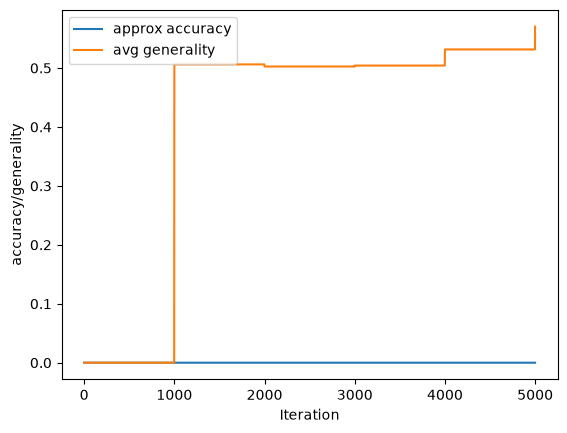

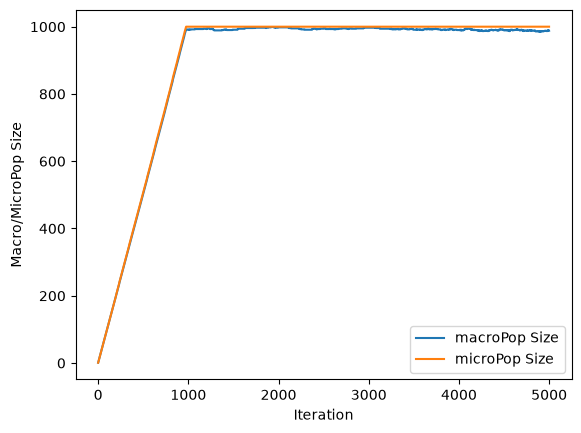

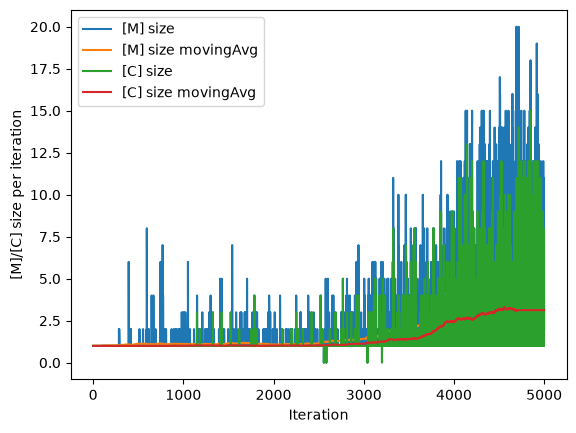

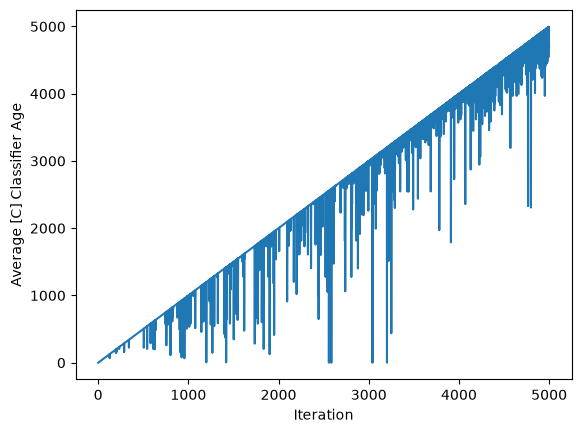

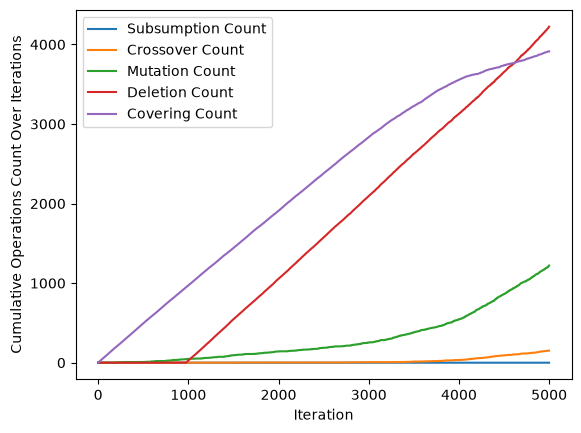

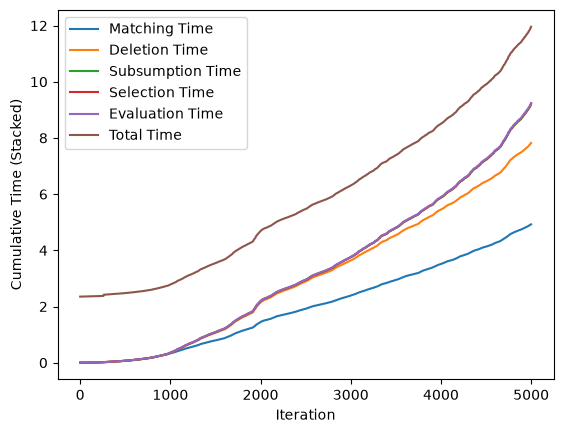

In [40]:
# Display the iteration tracking data for the baseline eLCS model
import numpy as np


def cumulativeFreq(freq):
    a = []
    c = []
    for i in freq:
        a.append(i + sum(c))
        c.append(i)
    return np.array(a)


def movingAvg(a, threshold=300):
    weights = np.repeat(1.0, threshold) / threshold
    conv = np.convolve(a, weights, "valid")
    return np.append(
        conv,
        np.full(threshold - 1, conv[conv.size - 1]),
    )


iterations = baseline_elcs_model_iteration_data["Iteration"].values
accuracy = baseline_elcs_model_iteration_data["Accuracy (approx)"].values
generality = baseline_elcs_model_iteration_data["Average Population Generality"].values
macroPop = baseline_elcs_model_iteration_data["Macropopulation Size"].values
microPop = baseline_elcs_model_iteration_data["Micropopulation Size"].values
mSize = baseline_elcs_model_iteration_data["Match Set Size"].values
cSize = baseline_elcs_model_iteration_data["Correct Set Size"].values
experience = baseline_elcs_model_iteration_data[
    "Average Iteration Age of Correct Set Classifiers"
].values
subsumption = baseline_elcs_model_iteration_data[
    "# Classifiers Subsumed in Iteration"
].values
crossover = baseline_elcs_model_iteration_data[
    "# Crossover Operations Performed in Iteration"
].values
mutation = baseline_elcs_model_iteration_data[
    "# Mutation Operations Performed in Iteration"
].values
covering = baseline_elcs_model_iteration_data[
    "# Covering Operations Performed in Iteration"
].values
deletion = baseline_elcs_model_iteration_data[
    "# Deletion Operations Performed in Iteration"
].values

gTime = baseline_elcs_model_iteration_data["Total Global Time"].values
mTime = baseline_elcs_model_iteration_data["Total Matching Time"].values
delTime = baseline_elcs_model_iteration_data["Total Deletion Time"].values
subTime = baseline_elcs_model_iteration_data["Total Subsumption Time"].values
selTime = baseline_elcs_model_iteration_data["Total Selection Time"].values
evalTime = baseline_elcs_model_iteration_data["Total Evaluation Time"].values

plt.plot(iterations, accuracy, label="approx accuracy")
plt.plot(iterations, generality, label="avg generality")
plt.xlabel("Iteration")
plt.ylabel("accuracy/generality")
plt.legend()
plt.show()

plt.plot(iterations, macroPop, label="macroPop Size")
plt.plot(iterations, microPop, label="microPop Size")
plt.xlabel("Iteration")
plt.ylabel("Macro/MicroPop Size")
plt.legend()
plt.show()

plt.plot(iterations, mSize, label="[M] size")
plt.plot(iterations, movingAvg(mSize), label="[M] size movingAvg")
plt.plot(iterations, cSize, label="[C] size")
plt.plot(iterations, movingAvg(cSize), label="[C] size movingAvg")
plt.xlabel("Iteration")
plt.ylabel("[M]/[C] size per iteration")
plt.legend()
plt.show()

plt.plot(iterations, experience)
plt.ylabel("Average [C] Classifier Age")
plt.xlabel("Iteration")
plt.show()

plt.plot(iterations, cumulativeFreq(subsumption), label="Subsumption Count")
plt.plot(iterations, cumulativeFreq(crossover), label="Crossover Count")
plt.plot(iterations, cumulativeFreq(mutation), label="Mutation Count")
plt.plot(iterations, cumulativeFreq(deletion), label="Deletion Count")
plt.plot(iterations, cumulativeFreq(covering), label="Covering Count")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Operations Count Over Iterations")
plt.legend()
plt.show()

plt.plot(iterations, mTime, label="Matching Time")
plt.plot(iterations, delTime + mTime, label="Deletion Time")
plt.plot(iterations, subTime + delTime + mTime, label="Subsumption Time")
plt.plot(iterations, selTime + subTime + delTime + mTime, label="Selection Time")
plt.plot(
    iterations, evalTime + selTime + subTime + delTime + mTime, label="Evaluation Time"
)
plt.plot(iterations, gTime, label="Total Time")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Time (Stacked)")
plt.legend()
plt.show()

In [41]:
# Export the final rule population to a CSV file

baseline_elcs_model_final_rule_population_file = (
    f"{export_dir}/baseline_elcs_model_final_rule_population.csv"
)

baseline_elcs_model.export_final_rule_population(
    X_baseline.columns.to_numpy(),
    "Completed",
    filename=baseline_elcs_model_final_rule_population_file,
    DCAL=False,
)

baseline_elcs_model_final_rule_populationData = pd.read_csv(
    baseline_elcs_model_final_rule_population_file
)
display(baseline_elcs_model_final_rule_populationData)

,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,...,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count
0,#,#,2.0,2.0,"7.890000000000001,18.11",0.0,2.0,#,4.0,4.0,...,1.000000,1.000000,1,1.000000,98,98,0.589744,0.000290,1,1
1,1.0,"12.04,21.96",#,0.0,"4.109999999999999,7.890000000000001",#,#,#,5.0,4.0,...,1.000000,1.000000,1,1.000000,218,218,0.512821,0.000290,1,1
2,0.0,#,3.0,0.0,"9.219999999999999,16.78",#,#,4.0,7.0,1.0,...,1.000000,1.000000,1,1.000000,221,221,0.641026,0.000290,1,1
3,#,"21.88,40.120000000000005",3.0,#,"1.7599999999999998,6.24",0.0,#,#,#,#,...,1.000000,1.000000,1,1.000000,341,224,0.384615,0.000290,2,2
4,#,#,#,0.0,#,0.0,#,3.0,#,#,...,1.000000,1.000000,1,1.000000,320,320,0.461538,0.000290,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,#,#,#,0.0,"3.87,12.129999999999999",#,#,#,#,#,...,0.000000,0.000000,1,8.000000,4997,4997,0.179487,0.002317,0,1
984,#,#,#,0.0,"3.87,12.129999999999999",#,#,#,#,#,...,0.000412,0.333333,1,6.666667,4997,4997,0.205128,0.001931,0,0
985,#,"18.64,41.36",#,#,"3.87,12.129999999999999",#,2.0,#,#,#,...,0.046266,0.857143,1,9.792000,4998,4998,0.256410,0.002836,0,0
986,#,#,#,0.0,"3.87,12.129999999999999",#,#,#,#,#,...,0.100000,1.000000,1,8.000000,4998,4998,0.205128,0.002317,0,0


Minimal processing: 
-Student_ID removed because it is only an identifier and not a meaningful predictor.
-Name removed because it is free-text/identifier information.
-Completed_Status removed because it was derived from the target and would cause target leakage.
-Enrollment_Date converted into numeric year/month/day values because eLCS requires numeric inputs.
-Categorical predictors such as Gender, City, Course_Level, etc. converted into numeric category codes so eLCS could process them.
-Completed converted from Completed / Not Completed into 1 / 0 because the model needs numeric class labels.
-No feature engineering, scaling, tuning, balancing, or optimisation was applied at this stage, so this remains the raw/minimally processed baseline.